# BRACT's
## Vishwakarma Institute of Technology, Pune
### Department of Computer Science & Engineering (Artificial Intelligence)
#### Practical Implementation Sheet — Deep Learning (DL)

---

| Parameter | Value |
|:---|:---|
| **Academic Year** | 2026-27 |
| **Semester** | 5 (TY SEM-1) |
| **Course** | Deep Learning |
| **Practical No.** | 3 |
| **Division & Batch** | Division: E | Batch: 3 |
| **Roll Number** | 70 |
| **PRN** | 12414995 |
| **Student Name** | Pushkar Patankar |

---

### Problem Statement
Implement **forward propagation** and **backpropagation** using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance.


In [1]:
# 1. Import Required Libraries, Load Dataset & Preprocess
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

In [2]:
def create_model(lr):
    m = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

   Learning Rate  Accuracy
0          0.100    0.7689
1          0.010    0.9702
2          0.001    0.9722


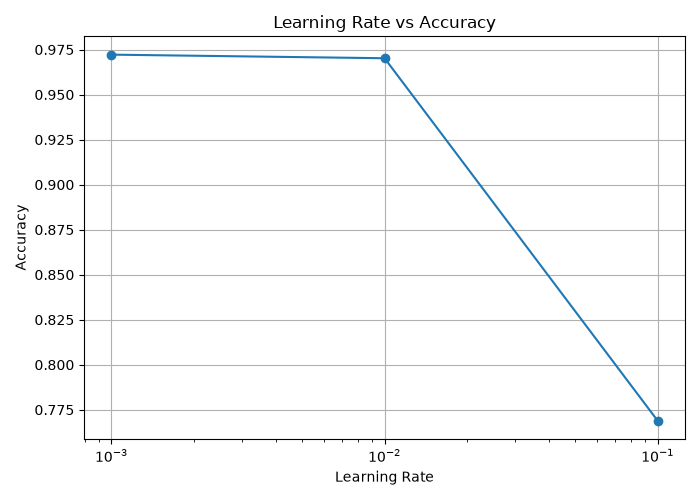

In [3]:
# 2. Compare Different Learning Rates :
learning_rates = [0.1, 0.01, 0.001]
results = []
for lr in learning_rates:
    model = create_model(lr)
    model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results.append([lr, acc])
df = pd.DataFrame(results, columns=['Learning Rate', 'Accuracy'])
print(df)
plt.plot(df['Learning Rate'], df['Accuracy'], marker='o')
plt.xscale('log'); plt.xlabel('Learning Rate'); plt.ylabel('Accuracy'); plt.title('Learning Rate vs Accuracy'); plt.grid(); plt.show()

   Epochs  Accuracy
0       5    0.9717
1      10    0.9762
2      20    0.9751


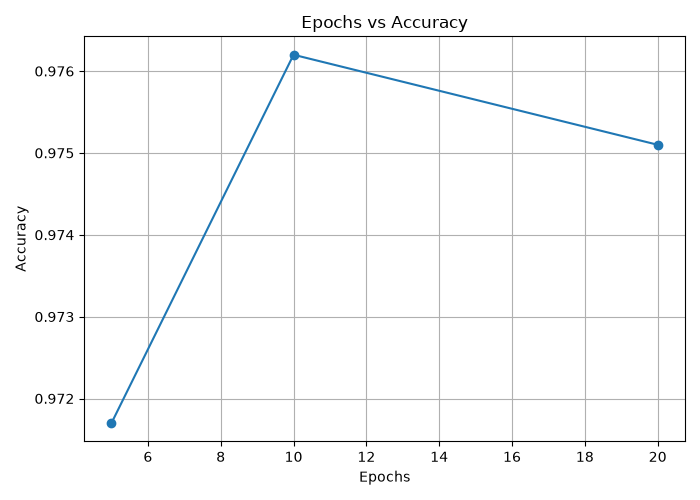

In [4]:
# 3. Compare Different Epochs :
epochs_list = [5, 10, 20]
res = []
for ep in epochs_list:
    model = create_model(0.001)
    h = model.fit(x_train, y_train, validation_split=0.2, epochs=ep, batch_size=128, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    res.append([ep, acc])
edf = pd.DataFrame(res, columns=['Epochs', 'Accuracy'])
print(edf)
plt.plot(edf['Epochs'], edf['Accuracy'], marker='o')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Epochs vs Accuracy'); plt.grid(); plt.show()

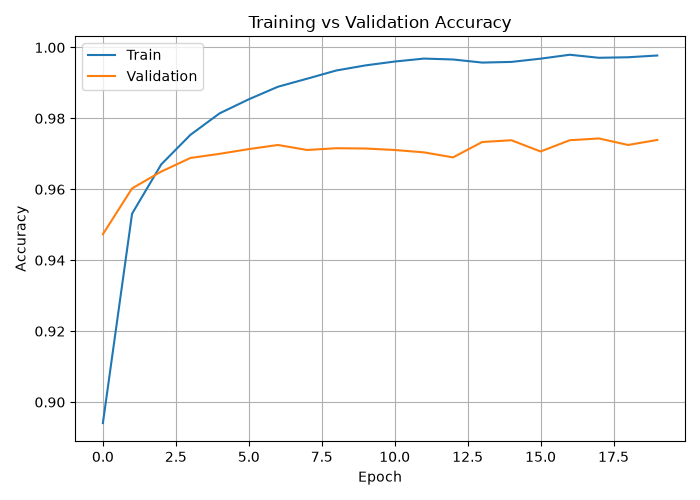

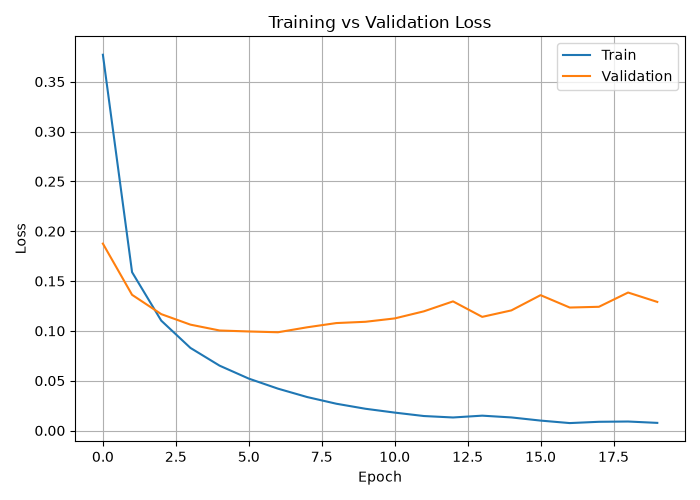

Test Loss: 0.1139, Test Accuracy: 0.9760
[0.11390656977891922, 0.9760000109672546]


In [5]:
# 4. Train Final Model, Plot Graphs & Evaluate :
model = create_model(0.001)
history = model.fit(x_train, y_train, validation_split=0.2, epochs=20, batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.title('Training vs Validation Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(['Train','Validation']); plt.grid(); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.title('Training vs Validation Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(['Train','Validation']); plt.grid(); plt.show()
print(model.evaluate(x_test, y_test))